In [2]:
import os
import sys

os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Fraud Detection AI")
    .getOrCreate()
)

# Load dataset
df = (
    spark.read
        .option("header", True)
        .option("inferSchema", True)
        .csv("../data/raw/creditcard.csv")
)

In [ ]:
spark.stop()

In [4]:
spark

In [2]:
#Print Schema
df.printSchema()

root
 |-- Time: double (nullable = true)
 |-- V1: double (nullable = true)
 |-- V2: double (nullable = true)
 |-- V3: double (nullable = true)
 |-- V4: double (nullable = true)
 |-- V5: double (nullable = true)
 |-- V6: double (nullable = true)
 |-- V7: double (nullable = true)
 |-- V8: double (nullable = true)
 |-- V9: double (nullable = true)
 |-- V10: double (nullable = true)
 |-- V11: double (nullable = true)
 |-- V12: double (nullable = true)
 |-- V13: double (nullable = true)
 |-- V14: double (nullable = true)
 |-- V15: double (nullable = true)
 |-- V16: double (nullable = true)
 |-- V17: double (nullable = true)
 |-- V18: double (nullable = true)
 |-- V19: double (nullable = true)
 |-- V20: double (nullable = true)
 |-- V21: double (nullable = true)
 |-- V22: double (nullable = true)
 |-- V23: double (nullable = true)
 |-- V24: double (nullable = true)
 |-- V25: double (nullable = true)
 |-- V26: double (nullable = true)
 |-- V27: double (nullable = true)
 |-- V28: double (nulla

In [3]:
# Dataset dimensions
num_rows = df.count()
num_columns = len(df.columns)

print(f"Rows: {num_rows:,}")
print(f"Columns: {num_columns}")

Rows: 284,807
Columns: 31


In [4]:
# ==========================
# Missing Values Analysis
# ==========================

from pyspark.sql.functions import col, when, sum

df.select(
    [
        sum(
            when(col(c).isNull(), 1).otherwise(0)
        ).alias(c)
        for c in df.columns
    ]
).show()

+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|Time| V1| V2| V3| V4| V5| V6| V7| V8| V9|V10|V11|V12|V13|V14|V15|V16|V17|V18|V19|V20|V21|V22|V23|V24|V25|V26|V27|V28|Amount|Class|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+
|   0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|  0|     0|    0|
+----+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+---+------+-----+



In [5]:
# ==========================================================
# DISTINCT - Compare Original vs Distinct DataFrame
# ==========================================================

# Remove duplicate rows (Transformation)
df_distinct = df.distinct()

# Compare row counts
original_rows = df.count()
distinct_rows = df_distinct.count()

print(f"Original rows : {original_rows:,}")
print(f"Distinct rows : {distinct_rows:,}")
print(f"Duplicates removed: {original_rows - distinct_rows:,}")

Original rows : 284,807
Distinct rows : 283,726
Duplicates removed: 1,081


In [9]:
# ==========================
# Fraud Distribution
# ==========================

from pyspark.sql import Row
from pyspark.sql.functions import (
    broadcast,
    col,
    round
)

# Create lookup table
class_df = spark.createDataFrame([
    Row(Class=0, Description="Normal Transaction"),
    Row(Class=1, Description="Fraud")
])

# Calculate transactions by class
transactions_df = (
    df
    .groupBy("Class")
    .count()
    .withColumnRenamed("count", "Transactions")
)

# Calculate total number of transactions
total_transactions = df.count()

# Calculate percentage of transactions
transactions_df = (
    transactions_df
    .withColumn(
        "Percentage",
        round(
            col("Transactions") / total_transactions * 100,
            4
        )
    )
)

# Join lookup table with results
result = (
    broadcast(class_df)   
    .join(
        transactions_df,
        on="Class",
        how="inner"
    )
    .orderBy("Class")
)

# Display results
result.show()

+-----+------------------+------------+----------+
|Class|       Description|Transactions|Percentage|
+-----+------------------+------------+----------+
|    0|Normal Transaction|      284315|   99.8273|
|    1|             Fraud|         492|    0.1727|
+-----+------------------+------------+----------+



In [5]:
# ==========================
# Transaction Amount Analysis
# ==========================

from pyspark.sql.functions import (
    avg,
    min,
    max,
    stddev,
    round
)

amount_stats_df = (
    df
    .groupBy("Class")
    .agg(
        round(avg("Amount"), 2).alias("Avg_Amount"),
        round(min("Amount"), 2).alias("Min_Amount"),
        round(max("Amount"), 2).alias("Max_Amount"),
        round(stddev("Amount"), 2).alias("StdDev_Amount")
    )
)

amount_stats_df.show()

+-----+----------+----------+----------+-------------+
|Class|Avg_Amount|Min_Amount|Max_Amount|StdDev_Amount|
+-----+----------+----------+----------+-------------+
|    1|    122.21|       0.0|   2125.87|       256.68|
|    0|     88.29|       0.0|  25691.16|       250.11|
+-----+----------+----------+----------+-------------+



In [7]:
class_df = spark.createDataFrame([
    Row(Class=0, Description="Normal Transaction"),
    Row(Class=1, Description="Fraud")
])


# Join transaction statistics with class descriptions
df_join = (
    broadcast(class_df)
    .join(
        amount_stats_df,
        on="Class",
        how="inner"
    )
    .orderBy("Class")
)

df_join.show()


+-----+------------------+----------+----------+----------+-------------+
|Class|       Description|Avg_Amount|Min_Amount|Max_Amount|StdDev_Amount|
+-----+------------------+----------+----------+----------+-------------+
|    0|Normal Transaction|     88.29|       0.0|  25691.16|       250.11|
|    1|             Fraud|    122.21|       0.0|   2125.87|       256.68|
+-----+------------------+----------+----------+----------+-------------+



In [9]:
# ==========================
# Time Analysis
# ==========================

#First and last timestamps in the dataset

time_stats_df = df.agg(
    min("Time").alias("First_Timestamp"),
    max("Time").alias("Last_Timestamp")
)

time_stats_df.show()

+---------------+--------------+
|First_Timestamp|Last_Timestamp|
+---------------+--------------+
|            0.0|      172792.0|
+---------------+--------------+



In [11]:
from pyspark.sql.functions import col, round

time_stats_df = (
    time_stats_df
    .withColumn(
        "Duration_Days",
        round(
            (col("Last_Timestamp") - col("First_Timestamp")) / (24 * 60 * 60),
            2
        )
    )
)

time_stats_df.show()

+---------------+--------------+-------------+
|First_Timestamp|Last_Timestamp|Duration_Days|
+---------------+--------------+-------------+
|            0.0|      172792.0|          2.0|
+---------------+--------------+-------------+



In [15]:
from pyspark.sql.functions import col, floor

day_df = (
    df.withColumn(
        "Day", 
        floor(col("Time") / (24 * 60 * 60))
    )
)

In [10]:
transactions_per_day_df = (
    day_df
    .groupBy("Day") 
    .count()
    .orderBy("Day")
)

transactions_per_day_df.show()

+---+------+
|Day| count|
+---+------+
|  0|144786|
|  1|140021|
+---+------+



Observation:
The dataset spans approximately two days of transactions. The number of transactions is relatively balanced between both days, with no significant temporal imbalance observed.

In [5]:
# ==========================
# Amount Distribution
# ==========================



df.select("Amount").describe().show()

+-------+-----------------+
|summary|           Amount|
+-------+-----------------+
|  count|           284807|
|   mean|88.34961925093017|
| stddev|250.1201092401885|
|    min|              0.0|
|    max|         25691.16|
+-------+-----------------+



The standard deviation is high relative to the mean, suggesting that the observations are widely spread around the mean and that the variable exhibits considerable variability.

Observation: The Amount feature shows a highly dispersed distribution. While the average transaction amount is approximately €88, the maximum exceeds €25,000, suggesting the presence of significant outliers and a right-skewed distribution.

In [9]:
amount_percentiles = df.approxQuantile("Amount", [0.25, 0.5, 0.75], 0.01)

print(f"25th Percentile: {amount_percentiles[0]:,.2f}")
print(f"50th Percentile (Median): {amount_percentiles[1]:,.2f}")
print(f"75th Percentile: {amount_percentiles[2]:,.2f}") 

25th Percentile: 5.39
50th Percentile (Median): 21.15
75th Percentile: 74.95


In [10]:
amount_pd = (
    df
    .select("Amount")
    .toPandas()
)

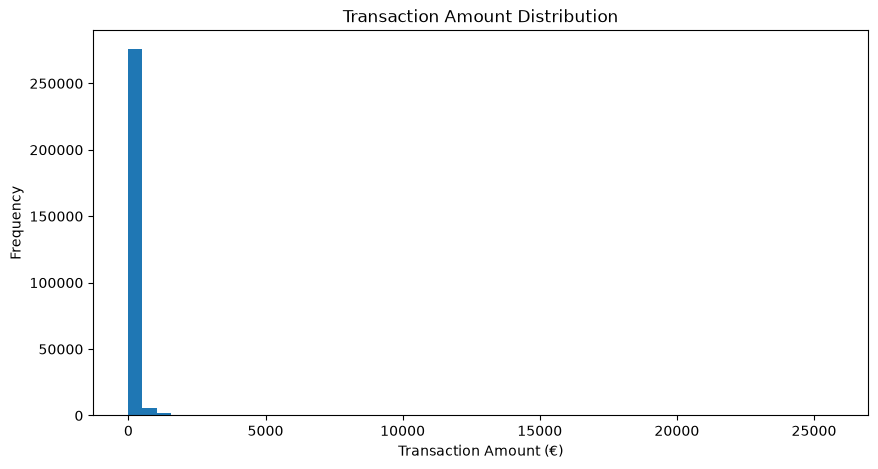

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    amount_pd["Amount"],
    bins=50
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Frequency")

plt.show()

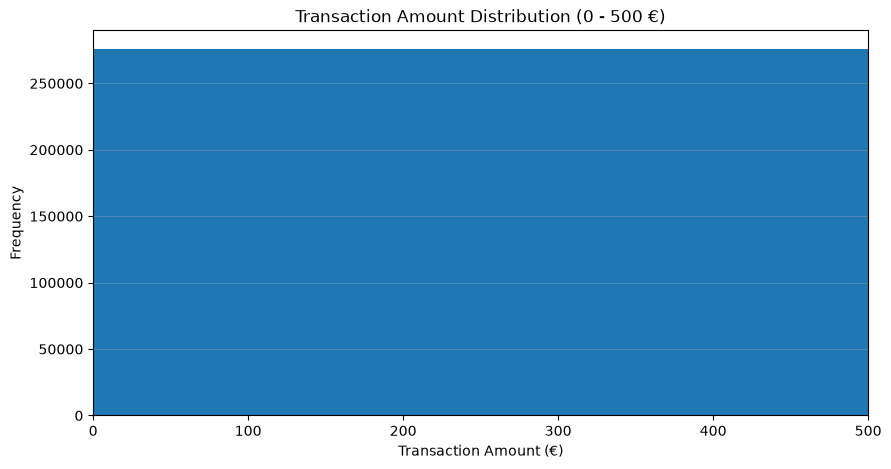

In [12]:
# ==========================
# Amount Distribution (0 - 500 €)
# ==========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(
    amount_pd["Amount"],
    bins=50
)

plt.xlim(0, 500)

plt.title("Transaction Amount Distribution (0 - 500 €)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

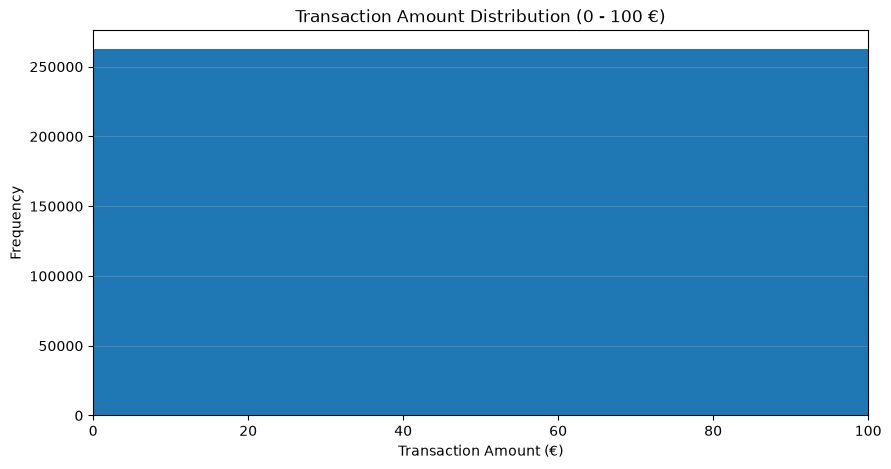

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    amount_pd["Amount"],
    bins=100
)

plt.xlim(0, 100)

plt.title("Transaction Amount Distribution (0 - 100 €)")
plt.xlabel("Transaction Amount (€)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [ ]:
amount_pd["Amount"].describe()


Amount
1.00     13688
1.98      6044
0.89      4872
9.99      4747
15.00     3280
0.76      2998
10.00     2950
1.29      2892
1.79      2623
0.99      2304
20.00     2002
0.00      1825
8.99      1811
11.50     1741
4.49      1579
5.00      1569
0.77      1443
2.69      1436
25.00     1388
50.00     1341
Name: count, dtype: int64

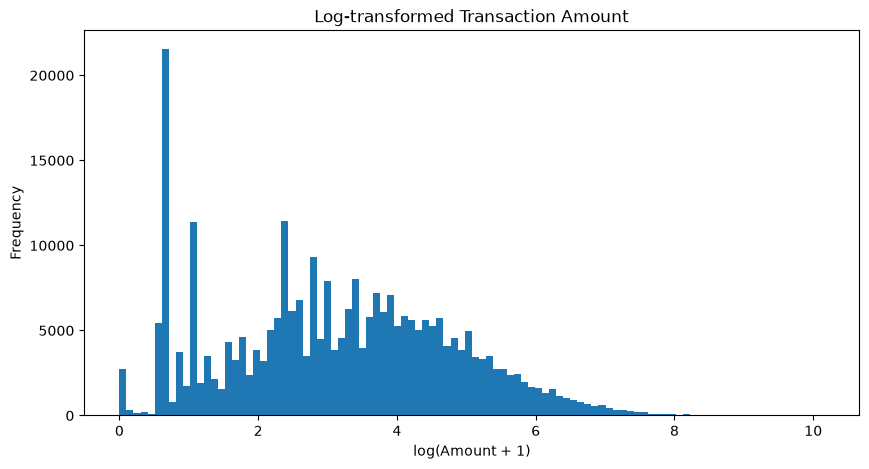

In [21]:
from pyspark.sql.functions import log1p

import numpy as np

amount_pd["Amount_Log"] = np.log1p(amount_pd["Amount"])


plt.figure(figsize=(10,5))

plt.hist(
    amount_pd["Amount_Log"],
    bins=100
)

plt.title("Log-transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")
plt.ylabel("Frequency")

plt.show()

Observation: After applying a logarithmic transformation, the transaction amount distribution becomes much easier to visualize. Most transactions are concentrated at low amounts, while a long right tail confirms the presence of relatively few high-value transactions. Several peaks are visible, suggesting that certain transaction amounts (e.g., €1, €10, €20, €50) occur much more frequently than others.

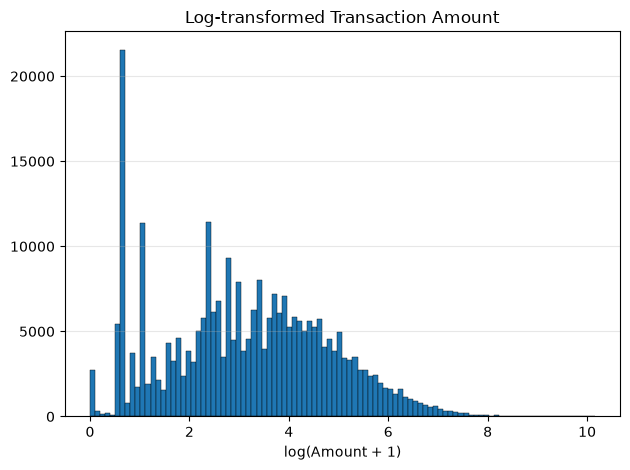

In [23]:
plt.hist(
    amount_pd["Amount_Log"],
    bins=100,
    edgecolor="black",
    linewidth=0.3
)

plt.title("Log-transformed Transaction Amount")
plt.xlabel("log(Amount + 1)")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

In [3]:
# ==========================
# Amount Analysis by Class
# ==========================

from pyspark.sql.functions import avg, min, max, stddev

amount_by_class_df = (
    df
    .groupBy("Class")
    .agg(
        avg("Amount").alias("Avg_Amount"),
        min("Amount").alias("Min_Amount"),
        max("Amount").alias("Max_Amount"),
        stddev("Amount").alias("StdDev_Amount")
    )
    .orderBy("Class")
)

amount_by_class_df.show()

+-----+------------------+----------+----------+------------------+
|Class|        Avg_Amount|Min_Amount|Max_Amount|     StdDev_Amount|
+-----+------------------+----------+----------+------------------+
|    0| 88.29102242231212|       0.0|  25691.16|250.10509222589246|
|    1|122.21132113821136|       0.0|   2125.87|256.68328829771207|
+-----+------------------+----------+----------+------------------+



Observation: Fraudulent transactions have a higher average amount (€122.21) than normal transactions (€88.29). However, the substantial overlap in the distributions means that transaction amount alone is unlikely to be sufficient to distinguish fraudulent transactions.

In [3]:
from pyspark.sql.functions import col

normal_percentiles = (
    df
    .filter(col("Class") == 0)
    .approxQuantile("Amount", [0.25, 0.5, 0.75], 0.01)
)

fraud_percentiles = (
    df
    .filter(col("Class") == 1)
    .approxQuantile("Amount", [0.25, 0.5, 0.75], 0.01)
)

In [4]:
print("Normal transactions:", normal_percentiles)
print("Fraud transactions:", fraud_percentiles)

Normal transactions: [5.49, 21.43, 74.95]
Fraud transactions: [1.0, 9.21, 104.81]


Observation:
Although fraudulent transactions have a higher mean amount (€122.21 vs €88.29), their median amount is substantially lower (€9.21 vs €21.43). The 75th percentile, however, is higher for fraudulent transactions (€104.81 vs €74.95). This suggests that fraudulent transactions have a more dispersed distribution, with many low-value transactions but also a relatively heavier upper tail.

In [3]:
# ==========================
# Amount Distribution by Class
# ==========================

amount_class_pd = (
    df
    .select("Amount", "Class")
    .toPandas()
)

<Figure size 800x500 with 0 Axes>

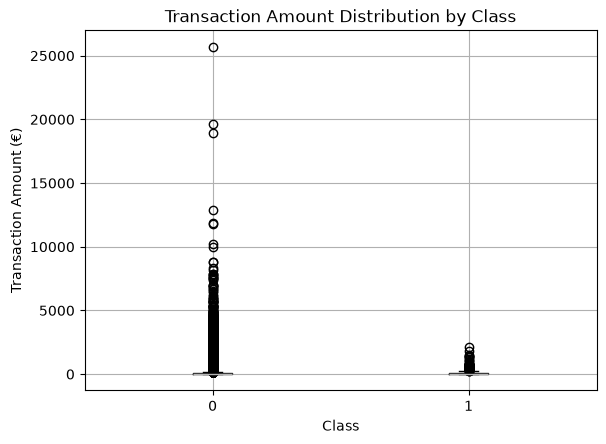

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

amount_class_pd.boxplot(
    column="Amount",
    by="Class"
)

plt.title("Transaction Amount Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Transaction Amount (€)")

plt.show()

<Figure size 800x500 with 0 Axes>

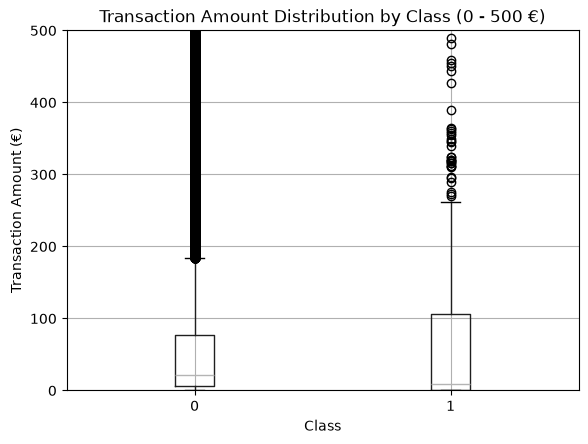

In [4]:
# ==========================
# Amount Distribution by Class (0 - 500 €)
# ==========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

amount_class_pd.boxplot(
    column="Amount",
    by="Class"
)

plt.ylim(0, 500)

plt.title("Transaction Amount Distribution by Class (0 - 500 €)")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Transaction Amount (€)")

plt.show()

Observation:
The boxplot confirms that fraudulent transactions have a lower median amount than normal transactions. However, their upper quartile is higher, indicating a wider upper distribution. Fraudulent transactions therefore tend to include many low-value transactions while also showing a significant number of relatively high-value transactions.

In [7]:
class_distribution_df = (
    df
    .groupBy("Class")
    .count()
    .orderBy("Class")
)

class_distribution_df.show()

+-----+------+
|Class| count|
+-----+------+
|    0|284315|
|    1|   492|
+-----+------+



In [13]:
# ==========================
# Class Distribution
# ==========================

from pyspark.sql.functions import col, round

class_distribution_df = (
    df
    .groupBy("Class")
    .count()
    .withColumnRenamed("count", "Count")
    .withColumn(
        "Percentage",
        round(col("Count") / total_transactions * 100, 4)
    )
    .orderBy("Class")
)

class_distribution_df.show()

+-----+------+----------+
|Class| Count|Percentage|
+-----+------+----------+
|    0|284315|   99.8273|
|    1|   492|    0.1727|
+-----+------+----------+



Observation:
The dataset is highly imbalanced. Normal transactions represent 99.8273% of the observations, while fraudulent transactions account for only 0.1727% (492 transactions). This severe class imbalance must be considered when training and evaluating fraud detection models.

In [17]:
fraud_per_day_df = (
    day_df
    .filter(col("Class") == 1)
    .groupBy("Day")
    .count()
    .orderBy("Day")
)

fraud_per_day_df.show()

+---+-----+
|Day|count|
+---+-----+
|  0|  281|
|  1|  211|
+---+-----+



In [18]:
# ==========================
# Fraud Rate by Day
# ==========================

total_per_day_df = (
    day_df
    .groupBy("Day")
    .count()
    .withColumnRenamed("count", "Total_Transactions")
)

fraud_per_day_df = (
    day_df
    .filter(col("Class") == 1)
    .groupBy("Day")
    .count()
    .withColumnRenamed("count", "Fraud_Transactions")
)

fraud_rate_by_day_df = (
    total_per_day_df
    .join(fraud_per_day_df, on="Day", how="left")
    .withColumn(
        "Fraud_Rate",
        round(
            col("Fraud_Transactions") /
            col("Total_Transactions") * 100,
            4
        )
    )
    .orderBy("Day")
)

fraud_rate_by_day_df.show()

+---+------------------+------------------+----------+
|Day|Total_Transactions|Fraud_Transactions|Fraud_Rate|
+---+------------------+------------------+----------+
|  0|            144786|               281|    0.1941|
|  1|            140021|               211|    0.1507|
+---+------------------+------------------+----------+

